2026-04-09 13:27:19 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\featured_data.csv
2026-04-09 13:27:20 - src.utils.file_handler - INFO - Successfully loaded 32593 rows and 53 columns
Dataset shape: (32593, 53)

Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'module_presentation_length', 'date_registration', 'date_unregistration', 'is_unregistered', 'total_clicks', 'avg_clicks_per_session', 'total_sessions', 'first_activity_date', 'last_activity_date', 'avg_score', 'std_score', 'min_score', 'max_score', 'num_assessments', 'avg_submission_date', 'num_banked', 'pass_fail', 'engagement_intensity', 'activity_span', 'early_engagement', 'high_engagement', 'no_engagement', 'score_range', 'passing_avg_score', 'low_avg_score', 'has_assessments', 'score_consistency', 'ear

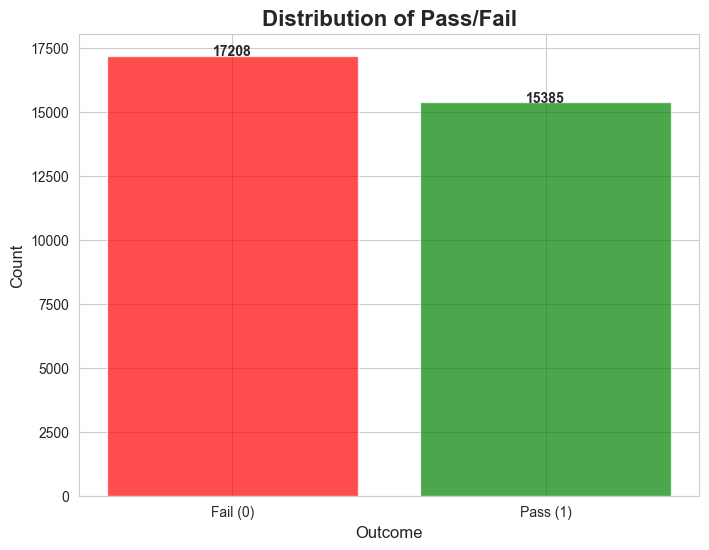

Pass: 15385 (47.2%)
Fail: 17208 (52.8%)


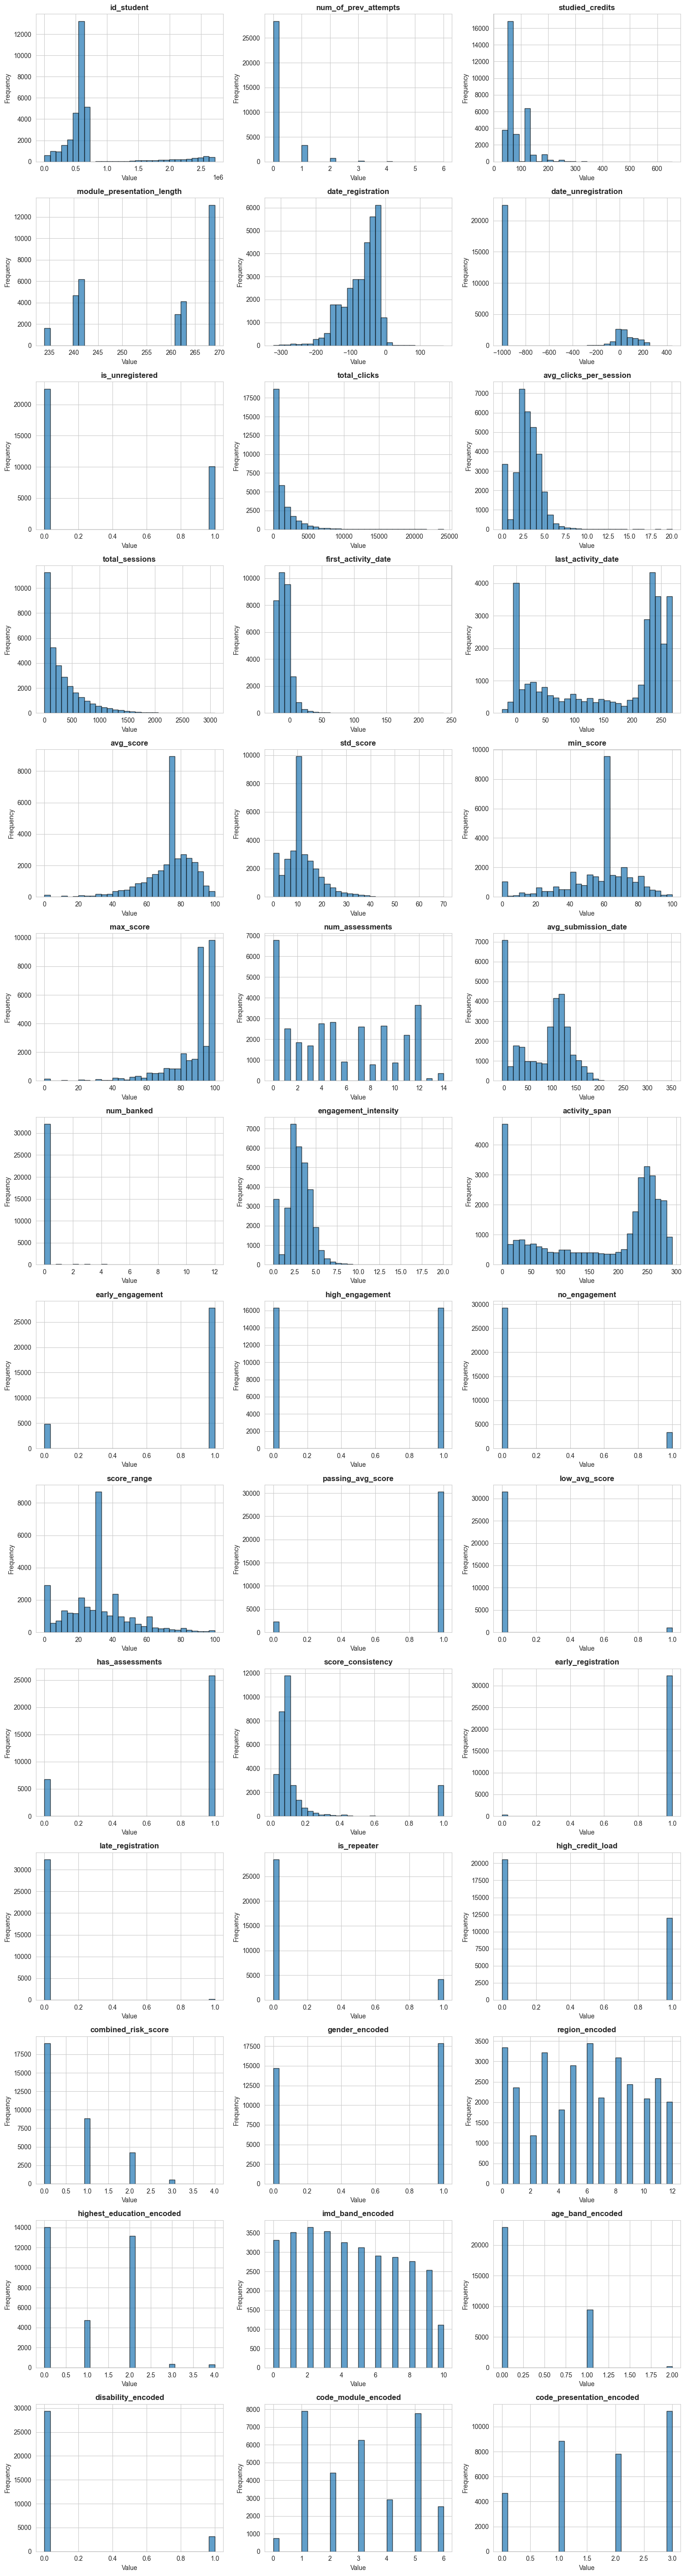

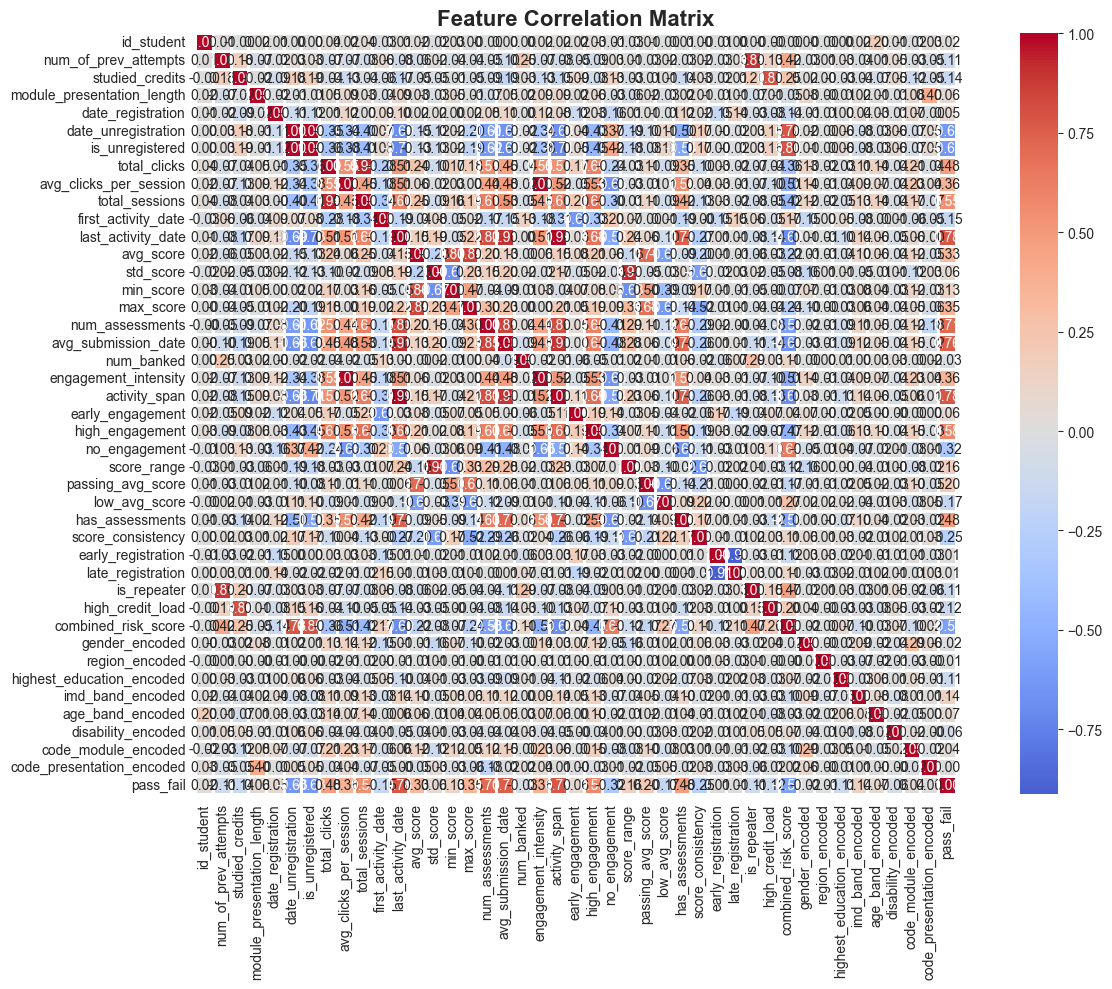

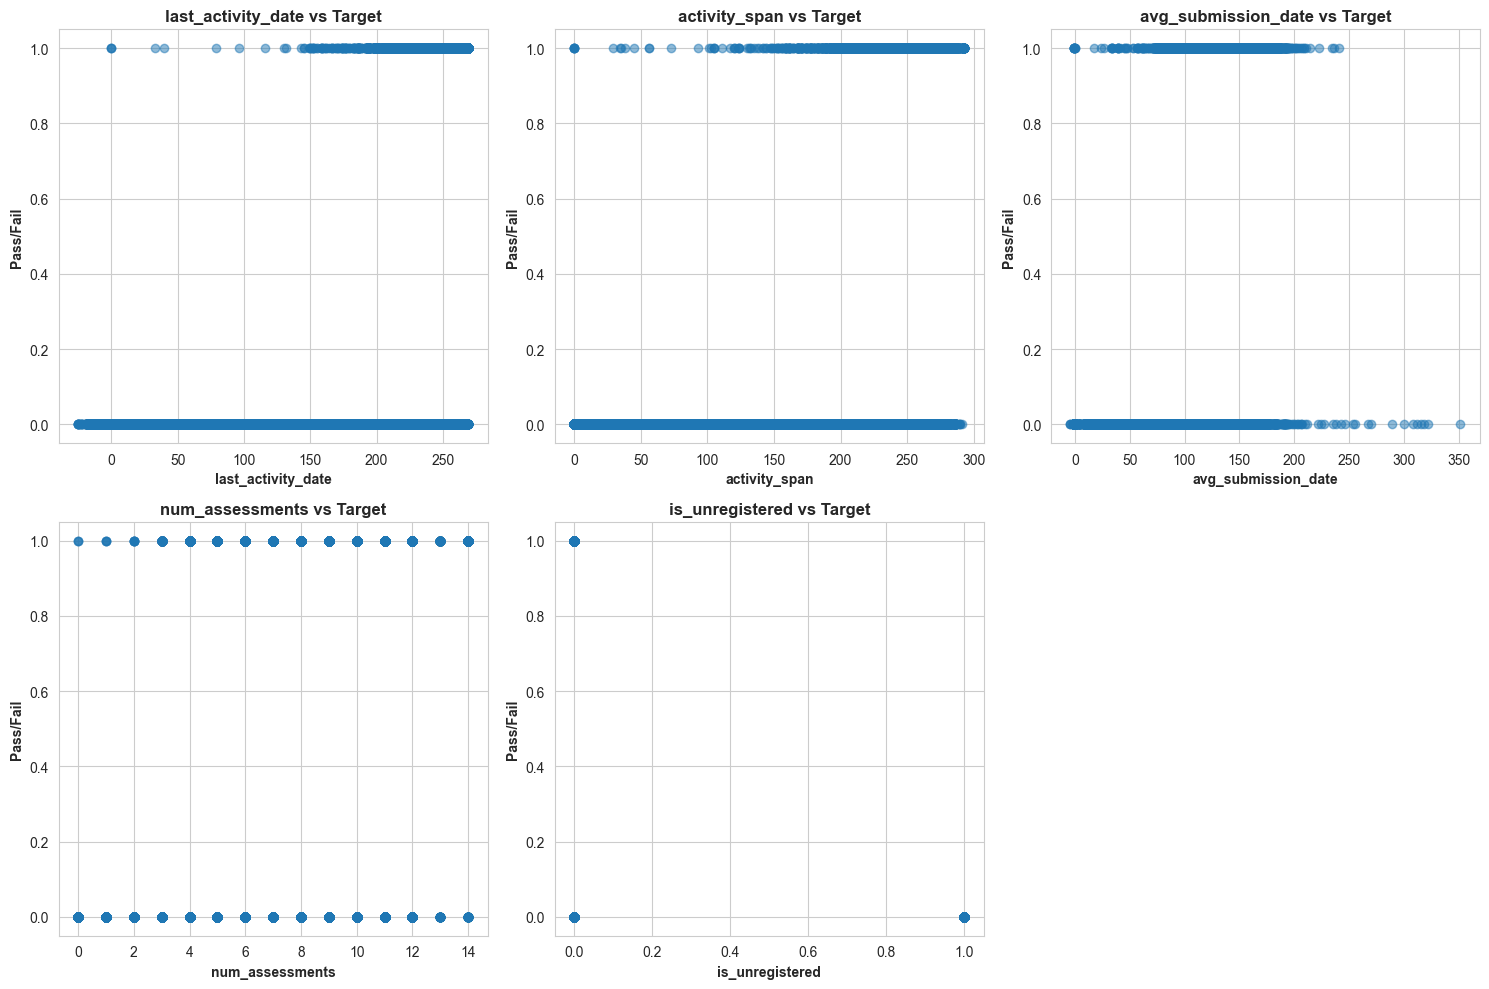

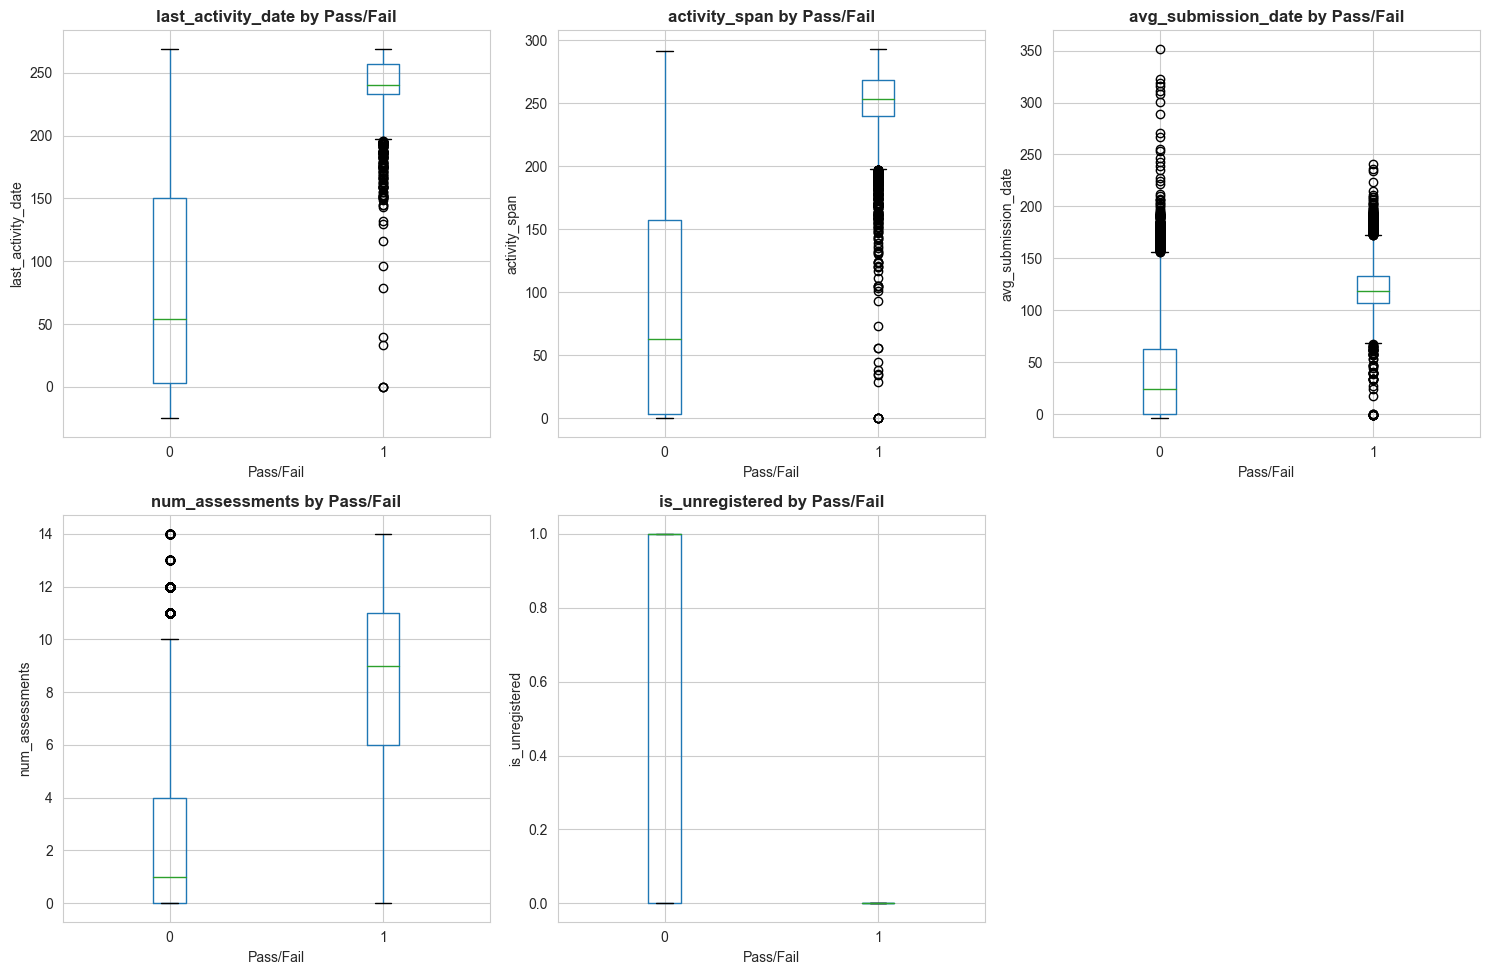

EXPLORATORY DATA ANALYSIS SUMMARY

Dataset Size: 32593 rows, 53 columns
Numeric Features: 42

Target Variable: pass_fail
  - Pass (1): 15385 (47.2%)
  - Fail (0): 17208 (52.8%)

Top 5 Correlated Features with Target:
  1. last_activity_date: 0.783
  2. activity_span: 0.777
  3. avg_submission_date: 0.756
  4. num_assessments: 0.715
  5. is_unregistered: -0.632

All figures saved to: c:\Users\M.SAMLY\Desktop\student performance prediction\outputs\figures


: 

In [ ]:
### notebooks/01_data_exploration.ipynb

# Jupyter Notebook - Create this file and add these cells

# Cell 1: Setup
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR
from src.utils.file_handler import load_csv, load_json

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cell 2: Load Data
df = load_csv(PROCESSED_DATA_DIR / "featured_data.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

# Cell 3: Basic Statistics
print("Dataset Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

# Cell 4: Target Distribution
plt.figure(figsize=(8, 6))
target_counts = df['pass_fail'].value_counts()
plt.bar(['Fail (0)', 'Pass (1)'], target_counts.values, color=['red', 'green'], alpha=0.7)
plt.title('Distribution of Pass/Fail', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Outcome', fontsize=12)

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Pass: {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")
print(f"Fail: {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")

# Cell 5: Numeric Features Distribution
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'pass_fail' in numeric_cols:
    numeric_cols.remove('pass_fail')

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(numeric_cols[:len(axes)]):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

# Hide empty subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell 6: Correlation Matrix
plt.figure(figsize=(14, 10))
correlation_matrix = df[numeric_cols + ['pass_fail']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell 7: Features vs Target
top_features = correlation_matrix['pass_fail'].abs().sort_values(ascending=False)[1:6].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['pass_fail'], alpha=0.5)
    axes[idx].set_xlabel(feature, fontweight='bold')
    axes[idx].set_ylabel('Pass/Fail', fontweight='bold')
    axes[idx].set_title(f'{feature} vs Target', fontweight='bold')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'features_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell 8: Box Plots by Target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    df.boxplot(column=feature, by='pass_fail', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Pass/Fail', fontweight='bold')
    axes[idx].set_xlabel('Pass/Fail')
    axes[idx].set_ylabel(feature)

axes[-1].axis('off')

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'boxplots_by_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell 9: Summary Report
print("="*60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)
print(f"\nDataset Size: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Numeric Features: {len(numeric_cols)}")
print(f"\nTarget Variable: pass_fail")
print(f"  - Pass (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")
print(f"  - Fail (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"\nTop 5 Correlated Features with Target:")
for i, feat in enumerate(top_features, 1):
    corr_val = correlation_matrix.loc[feat, 'pass_fail']
    print(f"  {i}. {feat}: {corr_val:.3f}")
print("\nAll figures saved to:", FIGURES_DIR)